In [1]:
# Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14,6)

In [4]:
# Load & Check Data

In [5]:
df = pd.read_csv('bitcoin_dataset.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df.set_index('Date', inplace=True)
df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100
...,...,...,...,...,...,...
2026-06-01,73580.210938,73969.570312,70599.507812,71319.773438,71319.773438,43378836121
2026-06-02,71321.031250,71334.953125,66127.265625,66703.656250,66703.656250,54990073882
2026-06-03,66694.007812,67402.929688,64009.675781,64014.367188,64014.367188,47411556213


In [6]:
print(df.shape)
df.head

(4280, 6)


<bound method NDFrame.head of                     Open          High           Low         Close  \
Date                                                                 
2014-09-17    465.864014    468.174011    452.421997    457.334015   
2014-09-18    456.859985    456.859985    413.104004    424.440002   
2014-09-19    424.102997    427.834991    384.532013    394.795990   
2014-09-20    394.673004    423.295990    389.882996    408.903992   
2014-09-21    408.084991    412.425995    393.181000    398.821014   
...                  ...           ...           ...           ...   
2026-06-01  73580.210938  73969.570312  70599.507812  71319.773438   
2026-06-02  71321.031250  71334.953125  66127.265625  66703.656250   
2026-06-03  66694.007812  67402.929688  64009.675781  64014.367188   
2026-06-04  64020.070312  64664.445312  61335.750000  63801.574219   
2026-06-05  63807.691406  63901.515625  59108.917969  60922.667969   

               Adj Close       Volume  
Date               

In [7]:
# Data Quality Check

In [8]:
# Check missing values
print(df.isnull().sum())

# Check for data gaps
date_diffs = df.index.to_series().diff().dt.days
print("\nGap distribution:")
print(date_diffs.value_counts().sort_index())

# Basic stats
df.describe()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Gap distribution:
Date
1.0    4279
Name: count, dtype: int64


,Open,High,Low,Close,Adj Close,Volume
count,4280.000000,4280.000000,4280.000000,4280.000000,4280.000000,4.280000e+03
mean,28623.330630,29188.324150,28019.749124,28636.451670,28636.451670,2.230348e+10
std,32442.204251,32986.012544,31852.792883,32442.454923,32442.454923,2.294359e+10
min,176.897003,211.731003,171.509995,178.102997,178.102997,5.914570e+06
25%,3452.187439,3504.092224,3391.943420,3458.813721,3458.813721,1.676575e+09
50%,11536.727539,11850.328613,11288.414062,11564.331543,11564.331543,1.802679e+10
75%,46401.472656,47432.591797,45184.174805,46446.924805,46446.924805,3.446429e+10
max,124752.140625,126198.070312,123196.046875,124752.531250,124752.531250,3.509679e+11


In [9]:
# Price history plot

Text(0, 0.5, 'Price(USD, lod scale)')

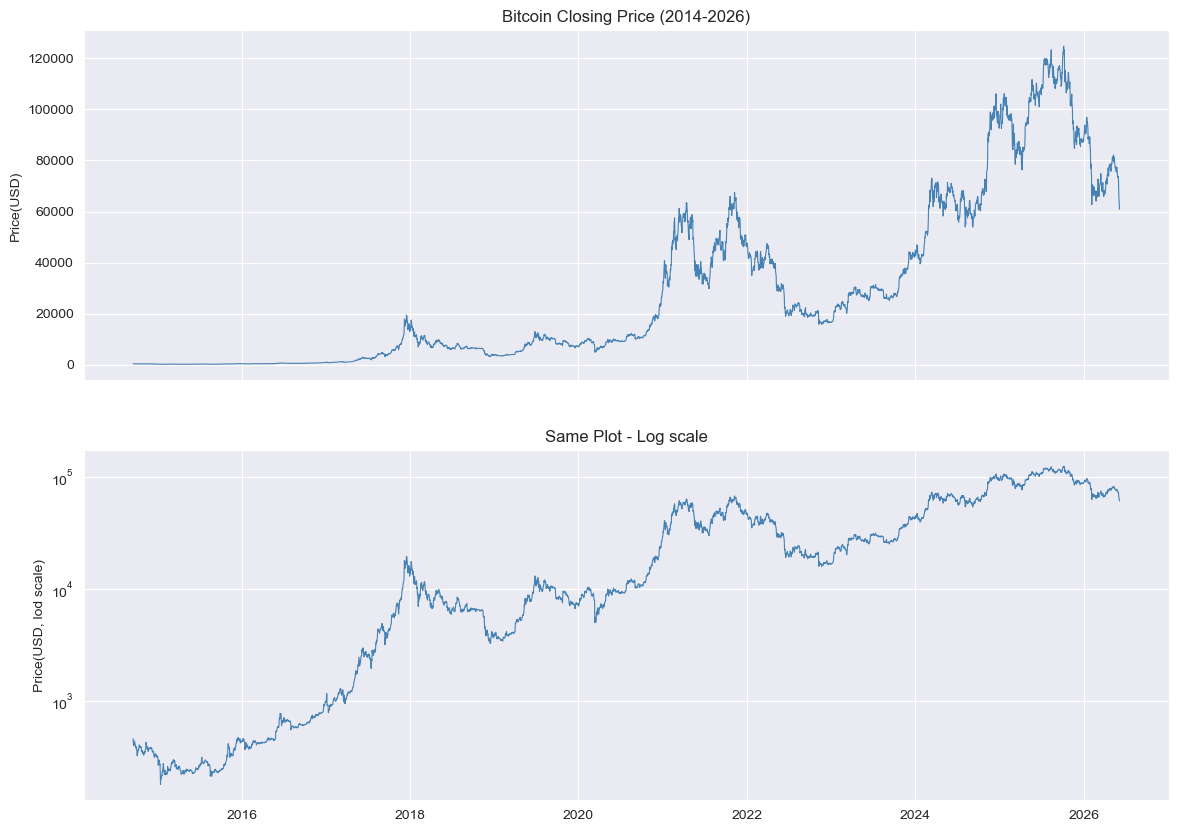

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, df['Close'], color='steelblue', linewidth=0.8)
axes[0].set_title('Bitcoin Closing Price (2014-2026)')
axes[0].set_ylabel('Price(USD)')

axes[1].plot(df.index, df['Close'],color='steelblue', linewidth=0.8)
axes[1].set_yscale('log')
axes[1].set_title('Same Plot - Log scale')
axes[1].set_ylabel('Price(USD, lod scale)')

In [11]:
# Daily returns

In [12]:
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
df['simple_return'] = df['Close'].pct_change()

df[['log_return', 'simple_return']].describe()

,log_return,simple_return
count,4279.000000,4279.000000
mean,0.001143,0.001758
std,0.035148,0.034916
min,-0.464730,-0.371695
25%,-0.012698,-0.012617
50%,0.001072,0.001073
75%,0.015759,0.015884
max,0.225119,0.252472


In [13]:
# Plot returns

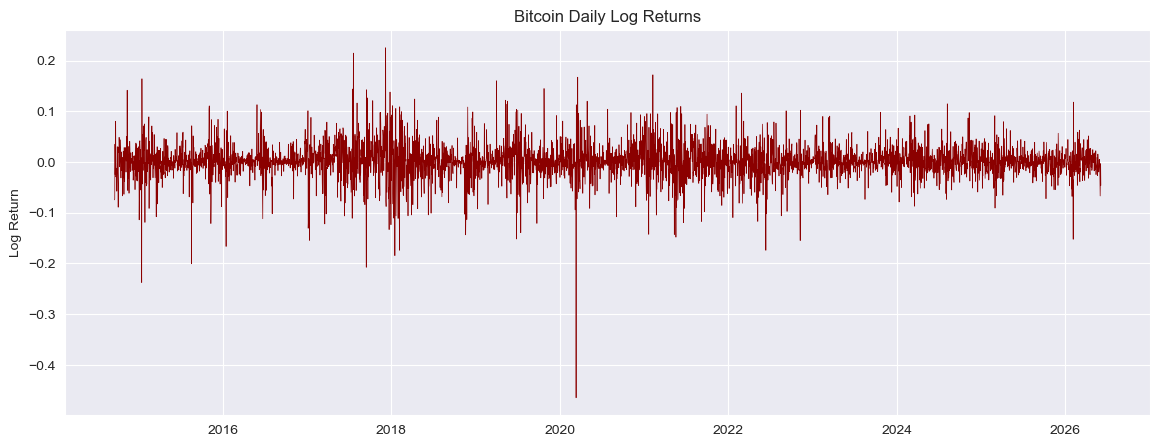

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['log_return'], color='darkred', linewidth=0.5)
ax.set_title('Bitcoin Daily Log Returns')
ax.set_ylabel('Log Return')
plt.show()

In [15]:
# Rolling Volatility

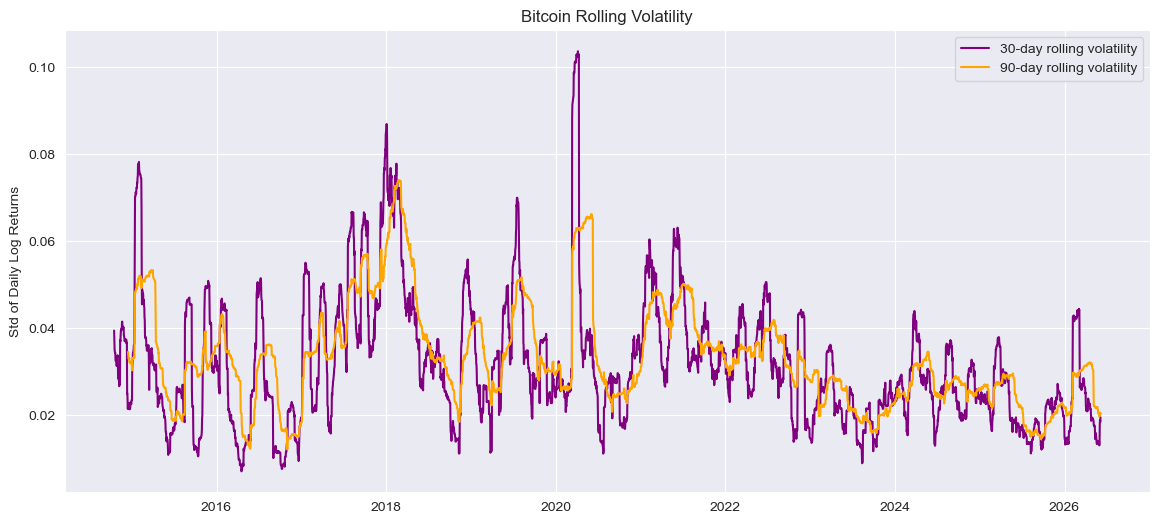

In [16]:
df['vol_7d'] = df['log_return'].rolling(7).std()
df['vol_30d'] = df['log_return'].rolling(30).std()
df['vol_90d'] = df['log_return'].rolling(90).std()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['vol_30d'], label='30-day rolling volatility', color='purple')
ax.plot(df.index, df['vol_90d'], label='90-day rolling volatility', color='orange', linewidth=1.5)
ax.set_title('Bitcoin Rolling Volatility')
ax.set_ylabel('Std of Daily Log Returns')
ax.legend()
plt.show()

In [17]:
# ADF Stationarity Test (this one needs a new import)

In [18]:
from statsmodels.tsa.stattools import adfuller

result_price = adfuller(df['Close'].dropna())
result_returns = adfuller(df['log_return'].dropna())

print(f"Price ADF p-value: {result_price[1]:.4f}")
print(f"Returns ADF p-value: {result_returns[1]:.4f}")

Price ADF p-value: 0.5799
Returns ADF p-value: 0.0000


In [19]:
# Phase 2 — Feature Engineering.
# RSI

In [20]:
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

df['RSI_14'] = compute_rsi(df['Close'])

In [21]:
# MACD

In [22]:
ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema_12 - ema_26
df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

In [23]:
# Bollinger Bands

In [24]:
df['BB_mid'] = df['Close'].rolling(20).mean()
bb_std = df['Close'].rolling(20).std()
df['BB_upper'] = df['BB_mid'] + 2 * bb_std
df['BB_lower'] = df['BB_mid'] - 2 * bb_std

In [25]:
# Visual check

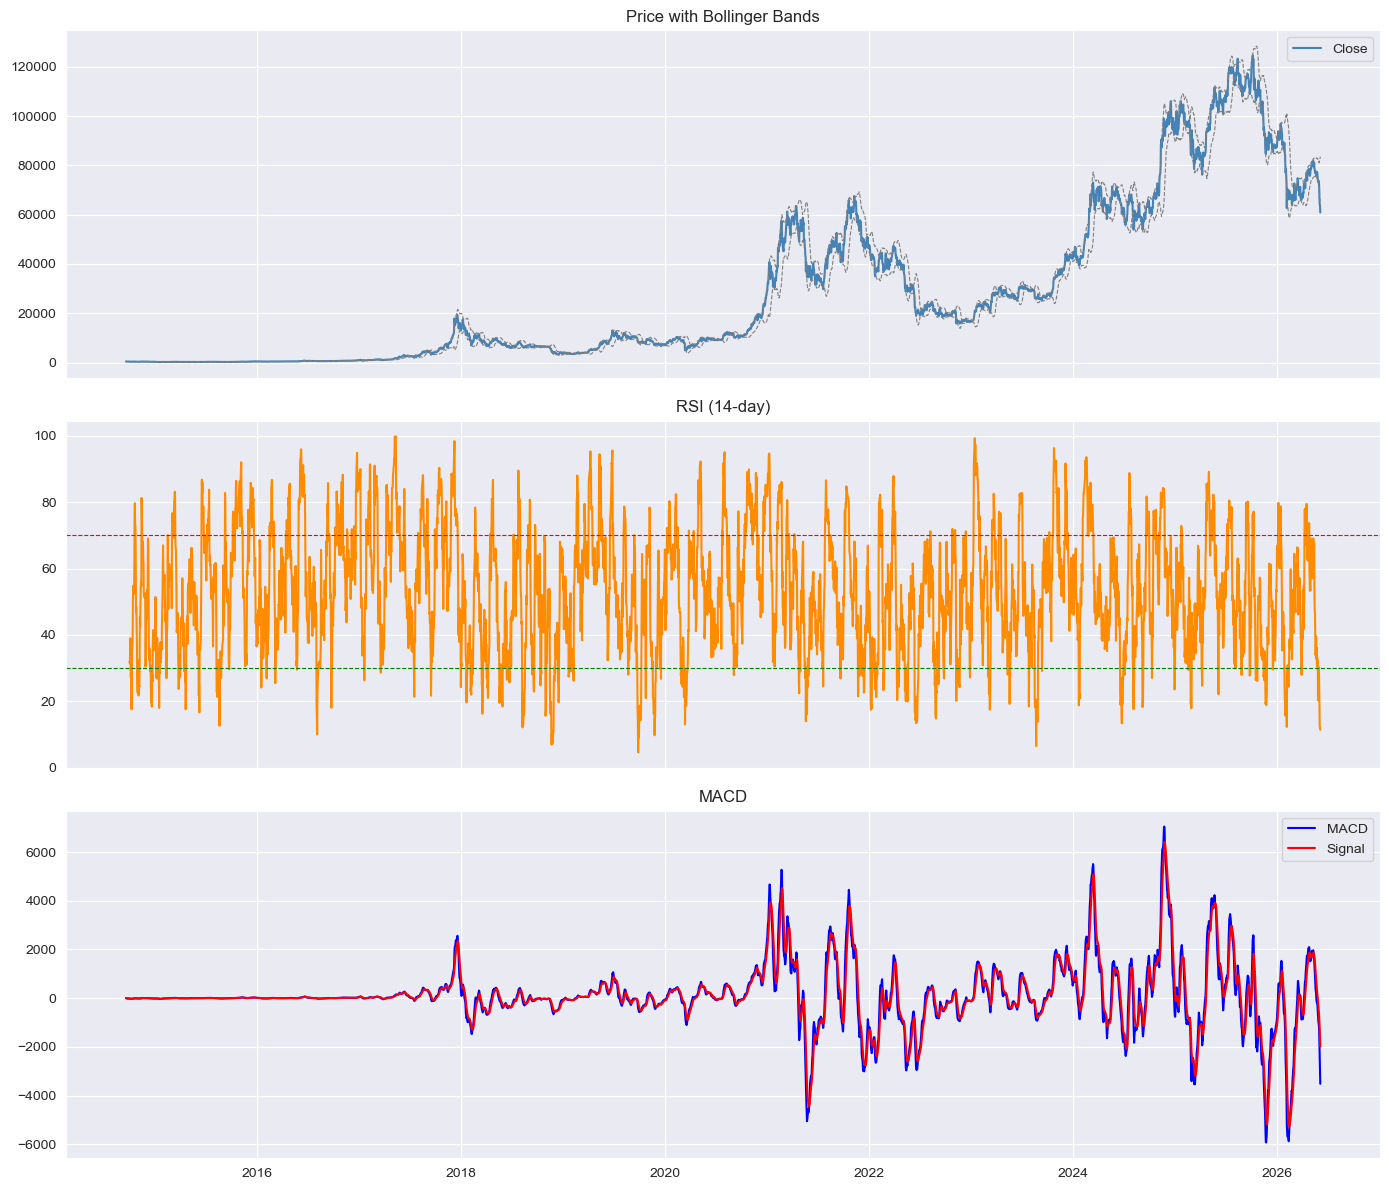

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

axes[0].plot(df.index, df['Close'], label='Close', color='steelblue')
axes[0].plot(df.index, df['BB_upper'], color='gray', linestyle='--', linewidth=0.8)
axes[0].plot(df.index, df['BB_lower'], color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title('Price with Bollinger Bands')
axes[0].legend()

axes[1].plot(df.index, df['RSI_14'], color='darkorange')
axes[1].axhline(70, color='red', linestyle='--', linewidth=0.8)
axes[1].axhline(30, color='green', linestyle='--', linewidth=0.8)
axes[1].set_title('RSI (14-day)')

axes[2].plot(df.index, df['MACD'], label='MACD', color='blue')
axes[2].plot(df.index, df['MACD_signal'], label='Signal', color='red')
axes[2].set_title('MACD')
axes[2].legend()

plt.tight_layout()
plt.show()

In [27]:
# Lag & Distribution Features

In [28]:
for lag in [1, 2, 3, 5, 7]:
    df[f'return_lag_{lag}'] = df['log_return'].shift(lag)

df['return_skew_30d'] = df['log_return'].rolling(30).skew()
df['return_kurt_30d'] = df['log_return'].rolling(30).kurt()
df['volume_change'] = df['Volume'].pct_change()

df[['return_lag_1', 'return_lag_2', 'return_skew_30d', 'return_kurt_30d', 'volume_change']].tail()

,return_lag_1,return_lag_2,return_skew_30d,return_kurt_30d,volume_change
Date,,,,,
2026-06-01,-0.002378,0.005197,-0.142280,-0.685407,1.486544
2026-06-02,-0.031195,-0.002378,-1.265405,3.175845,0.267671
2026-06-03,-0.066914,-0.031195,-1.120698,2.200931,-0.137816
2026-06-04,-0.041152,-0.066914,-1.151748,2.460855,0.345667
2026-06-05,-0.003330,-0.041152,-0.977558,1.448093,0.120148


In [29]:
# Train/Test Split (time-aware, not random!)

In [30]:
from arch import arch_model

# Use returns in percentage terms (arch library convention)
returns = df['log_return'].dropna() * 100

# Time-based split - last 90 days as test set
split_idx = len(returns) - 90
train, test = returns[:split_idx], returns[split_idx:]

print(f"Train size: {len(train)}, Test size: {len(test)}")

Train size: 4189, Test size: 90


In [32]:
# Fit GARCH(1,1)

In [33]:
model = arch_model(train, vol='GARCH', p=1, q=1, dist='t')  # Student-t distribution for fat tails
result = model.fit(disp='off')
print(result.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                   log_return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -10326.5
Distribution:      Standardized Student's t   AIC:                           20663.0
Method:                  Maximum Likelihood   BIC:                           20694.7
                                              No. Observations:                 4189
Date:                      Sat, Jun 27 2026   Df Residuals:                     4188
Time:                              09:39:40   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

In [34]:
# Forecast & Evaluate

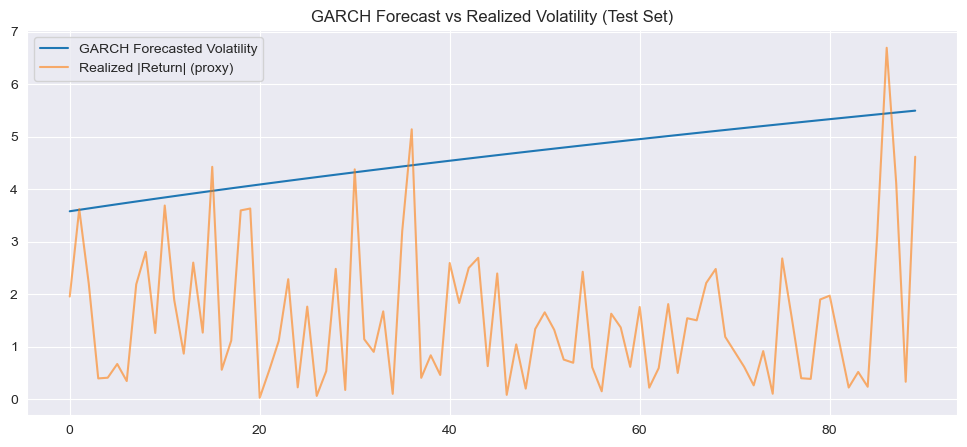

In [35]:
forecasts = result.forecast(horizon=90, reindex=False)
predicted_vol = np.sqrt(forecasts.variance.values[-1, :])

# Realized volatility in test set (rolling 1-day, since these are daily forecasts)
realized_vol = test.abs().values  # simple proxy: |return| as realized vol proxy

plt.figure(figsize=(12,5))
plt.plot(predicted_vol, label='GARCH Forecasted Volatility')
plt.plot(realized_vol, label='Realized |Return| (proxy)', alpha=0.6)
plt.legend()
plt.title('GARCH Forecast vs Realized Volatility (Test Set)')
plt.show()

In [56]:
import sys
print(sys.executable)

C:\Users\HP\anaconda3\python.exe


In [58]:
import sys
!{sys.executable} -m pip install arch

  Using cached arch-8.0.0-cp313-cp313-win_amd64.whl.metadata (13 kB)
Using cached arch-8.0.0-cp313-cp313-win_amd64.whl (929 kB)


In [36]:
# An improved version — a rolling one-step-ahead forecast

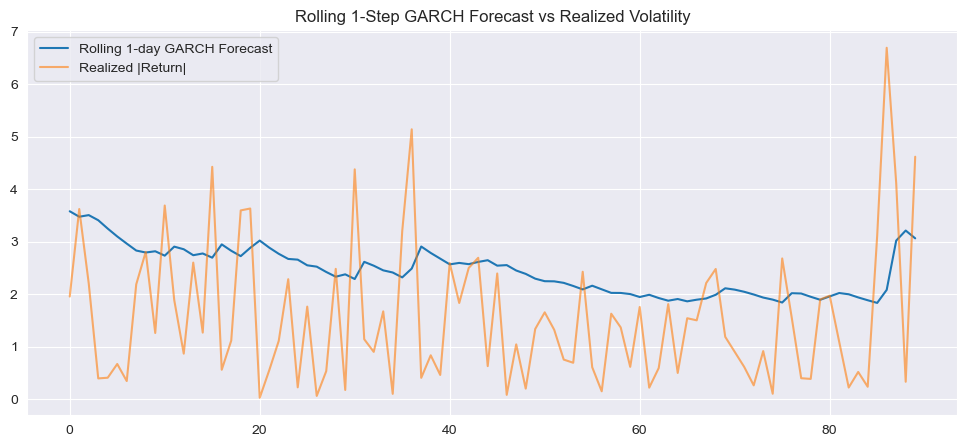

In [37]:
rolling_preds = []
for i in range(len(test)):
    current_train = returns[:split_idx+i]
    m = arch_model(current_train, vol='GARCH', p=1, q=1, dist='t')
    r = m.fit(disp='off')
    f = r.forecast(horizon=1, reindex=False)
    rolling_preds.append(np.sqrt(f.variance.values[-1,0]))

plt.figure(figsize=(12,5))
plt.plot(rolling_preds, label='Rolling 1-day GARCH Forecast')
plt.plot(test.abs().values, label='Realized |Return|', alpha=0.6)
plt.legend()
plt.title('Rolling 1-Step GARCH Forecast vs Realized Volatility')
plt.show()

In [ ]:
# Compute correlation between rolling_preds and test.abs().values to show the forecast tracks direction even if not magnitude.

In [38]:
corr = np.corrcoef(rolling_preds, test.abs().values)[0,1]
print(f"Correlation between forecasted and realized volatility: {corr:.3f}")

Correlation between forecasted and realized volatility: 0.114


In [ ]:








git add .
git commit -m "Phase 3: GARCH(1,1) volatility modeling - static and rolling forecasts"
git push